In [1]:
import warnings
warnings.simplefilter(action='ignore')

import os, joblib
import datetime, pandas

from tqdm import tqdm
from dataclasses import dataclass, asdict
import matplotlib.pyplot as plt

import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Union
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
from abc import ABC, abstractmethod

import kaggle_evaluation.default_inference_server

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoLars
from sklearn.linear_model import Lasso
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import TweedieRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestCentroid

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import CategoricalNB

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [2]:
train = pandas.read_csv('/kaggle/input/hull-tactical-market-prediction/train.csv').dropna()
test = pandas.read_csv('/kaggle/input/hull-tactical-market-prediction/test.csv').dropna()

In [3]:
train.columns

Index(['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1',
       'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19',
       'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3',
       'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13',
       'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7',
       'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5',
       'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4',
       'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2',
       'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'forward_returns',
       'risk_free_rate', 'market_forward_excess_returns'],
      dtype='object')

In [4]:
def preprocessing(data, typ):
    main_featurs = ['E1','E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19',
                    'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9',
                    "S2", "P9", "S1", "S5", "I2", "P8",
                    "P10", "P12", "P13"]
    
    if typ == "train":
        data = data[main_featurs + ["forward_returns"]]
    else:
        data = data[main_featurs]
    
    for i in zip(data.columns, data.dtypes):
        data[i[0]].fillna(0, inplace=True)

    return data

train = preprocessing(train, "train")

train_split, val_split = train_test_split(
    train, test_size=0.1, random_state=42
)

train_x = train_split.drop(columns=["forward_returns"])
test_x = val_split.drop(columns=["forward_returns"])
train_y = train_split['forward_returns']
test_y = val_split['forward_returns']

In [5]:
class score_compiler:
    def __init__(self, model, test_x, test_y):
        self.model = model
        self.X_test, self.y_test = test_x, test_y
    
    def evaluate(self, plot=True, n_samples=100, figsize=(12, 8)):
        y_pred, mape_loss, total_loss = self._calculate_losses()
        
        if plot:
            self._create_plots(y_pred, n_samples, figsize)
        
        return y_pred, mape_loss, total_loss
    
    def _calculate_losses(self):
        y_pred = self.model.predict(self.X_test)
        y_pred = np.array([i if i >= 50 else 0 for i in y_pred])
        
        total_loss = r2_score(self.y_test, y_pred)
        mape_loss = []
        for actual, predicted in zip(self.y_test, y_pred):
            mape_loss.append(mean_absolute_percentage_error([actual], [predicted]))
        
        return y_pred, np.array(mape_loss), total_loss
    
    def _create_plots(self, y_pred, n_samples, figsize):
        n_plot = min(n_samples, len(self.y_test))
        y_test_array = self.y_test.to_numpy() if hasattr(self.y_test, 'to_numpy') else np.array(self.y_test)
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Model Evaluation Results', fontsize=16, fontweight='bold')
        
        axes[0, 0].plot(y_test_array[:n_plot], label='Actual', color='blue', alpha=0.7, linewidth=2)
        axes[0, 0].plot(y_pred[:n_plot], label='Predicted', color='red', alpha=0.7, linewidth=2)
        axes[0, 0].set_title(f'Actual vs Predicted (First {n_plot} samples)')
        axes[0, 0].set_xlabel('Sample Index')
        axes[0, 0].set_ylabel('Value')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].scatter(y_test_array, y_pred, alpha=0.6, s=20)
        min_val = min(np.min(y_test_array), np.min(y_pred))
        max_val = max(np.max(y_test_array), np.max(y_pred))
        axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Prediction')
        axes[0, 1].set_title('Actual vs Predicted Scatter Plot')
        axes[0, 1].set_xlabel('Actual Values')
        axes[0, 1].set_ylabel('Predicted Values')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        residuals = y_test_array - y_pred
        axes[1, 0].scatter(y_pred, residuals, alpha=0.6, s=20)
        axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.8)
        axes[1, 0].set_title('Residuals Plot')
        axes[1, 0].set_xlabel('Predicted Values')
        axes[1, 0].set_ylabel('Residuals (Actual - Predicted)')
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 1].axvline(np.mean(residuals), color='red', linestyle='--', 
                          label=f'Mean: {np.mean(residuals):.2f}')
        axes[1, 1].set_title('Distribution of Residuals')
        axes[1, 1].set_xlabel('Residual Value')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def create_detailed_comparison_plot(self, n_samples=100, figsize=(15, 6)):
        y_pred, _, total_loss = self._calculate_losses()
        n_plot = min(n_samples, len(self.y_test))
        
        y_test_array = self.y_test.to_numpy() if hasattr(self.y_test, 'to_numpy') else np.array(self.y_test)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        x_axis = range(n_plot)
        ax1.plot(x_axis, y_test_array[:n_plot], 'o-', label='Actual', 
                color='blue', markersize=4, alpha=0.7)
        ax1.plot(x_axis, y_pred[:n_plot], 's-', label='Predicted', 
                color='red', markersize=4, alpha=0.7)
        ax1.set_title(f'Time Series Comparison\nMAPE: {total_loss:.4f}')
        ax1.set_xlabel('Sample Index')
        ax1.set_ylabel('Value')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        n_bar = min(20, n_plot)
        x_pos = np.arange(n_bar)
        width = 0.35
        
        ax2.bar(x_pos - width/2, y_test_array[:n_bar], width, label='Actual', 
               color='blue', alpha=0.7)
        ax2.bar(x_pos + width/2, y_pred[:n_bar], width, label='Predicted', 
               color='red', alpha=0.7)
        ax2.set_title(f'Bar Comparison (First {n_bar} samples)')
        ax2.set_xlabel('Sample Index')
        ax2.set_ylabel('Value')
        ax2.set_xticks(x_pos)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def print_evaluation_summary(self):
        y_pred, mape_loss, total_loss = self._calculate_losses()
        y_test_array = self.y_test.to_numpy() if hasattr(self.y_test, 'to_numpy') else np.array(self.y_test)
        
        residuals = y_test_array - y_pred
        
        print("="*50)
        print("MODEL EVALUATION SUMMARY")
        print("="*50)
        print(f"Total samples: {len(y_test_array)}")
        print(f"Overall R2: {total_loss:.4f}")
        print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.4f}")
        print(f"Root Mean Square Error: {np.sqrt(np.mean(residuals**2)):.4f}")
        print(f"Mean Residual: {np.mean(residuals):.4f}")
        print(f"Std Residual: {np.std(residuals):.4f}")
        print(f"Min Residual: {np.min(residuals):.4f}")
        print(f"Max Residual: {np.max(residuals):.4f}")
        
        zero_predictions = np.sum(y_pred == 0)
        print(f"Predictions set to 0 (< 50): {zero_predictions}/{len(y_pred)} ({100*zero_predictions/len(y_pred):.1f}%)")
        print("="*50)

In [6]:
catboost_params = {'iterations' : 5000,
                   'learning_rate': 0.009, 
                   'depth': 5, 
                   'l2_leaf_reg': 5.5,
                   'min_child_samples' : 102,
                   'od_wait' : 50,
                   'random_state' : 42,
                   'eval_metric': 'MAE', 
                   'od_type' : 'Iter',
                   'bootstrap_type': 'Bayesian', 
                   'grow_policy' : 'Depthwise',
                   'logging_level' : 'Silent'}

LGBM_R_parm = {'boosting_type': 'gbdt', 
               'colsample_bytree': 0.9484106149593443, 
               'learning_rate': 0.1988123373955639, 
               'max_bin': 77, 
               'max_depth': 10, 
               'metric': 'mape', 
               'min_child_samples': 81, 
               'min_data_in_leaf': 21, 
               'n_estimators': 5029, 
               'num_leaves': 42, 
               'objective': 'regression_l1', 
               'reg_alpha': 0.6355835028602363, 
               'reg_lambda': 3.109823217156622, 
               'subsample': 0.7300733288106989, 
               'verbosity': -1}

R_Forest_parm = {'criterion': 'absolute_error', 
                 'max_depth': 6, 'max_features': 'sqrt', 
                 'max_leaf_nodes': 42, 
                 'min_samples_leaf': 6, 
                 'min_samples_split': 13, 
                 'min_weight_fraction_leaf': 0.0023062425041415757, 
                 'n_estimators': 108, 
                 'random_state': 42}

Extra_parm = {'criterion': 'absolute_error', 
              'max_depth': 6, 'max_features': 'sqrt', 
              'max_leaf_nodes': 42, 
              'min_samples_leaf': 6, 
              'min_samples_split': 13, 
              'min_weight_fraction_leaf': 0.0023062425041415757, 
              'n_estimators': 108, 
              'random_state': 42}

GB_params = {'learning_rate' : 0.1, 
             'min_samples_split' : 500,
             'min_samples_leaf' : 50,
             'max_depth' : 8,
             'max_features' : 'sqrt',
             'subsample' : 0.8,
             'random_state' : 10}

print(f'CatBoostRegressor TRAINING...')
catboost = CatBoostRegressor(**catboost_params)
cat_features = list(train_x.select_dtypes(include=['object', 'category']).columns)
train_pool = Pool(train_x, train_y, cat_features=cat_features)
val_pool = Pool(test_x, test_y, cat_features=cat_features)
catboost.fit(train_pool, eval_set=(val_pool), verbose=100, early_stopping_rounds=100)
joblib.dump(catboost, f'catboost.pkl')

print(f'LGBMRegressor TRAINING...')
LGBM_R = LGBMRegressor(**LGBM_R_parm)
LGBM_R.fit(train_x, train_y, eval_set = [(test_x, test_y)])
joblib.dump(LGBM_R, f'LGBM_R.pkl')

print(f'RandomForestRegressor TRAINING...')
random_forest = RandomForestRegressor(**R_Forest_parm)
random_forest.fit(train_x, train_y)
joblib.dump(random_forest, f'random_forest.pkl')

print(f'ExtraTreesRegressor TRAINING...')
extra_trees = ExtraTreesRegressor(**Extra_parm)
extra_trees.fit(train_x, train_y)
joblib.dump(extra_trees, f'extra_trees.pkl')

print(f'GradientBoostingRegressor TRAINING...')
GradientBoosting = GradientBoostingRegressor(**GB_params)
GradientBoosting.fit(train_x, train_y)
joblib.dump(GradientBoosting, f'GradientBoosting.pkl')

CatBoostRegressor TRAINING...
LGBMRegressor TRAINING...
RandomForestRegressor TRAINING...
ExtraTreesRegressor TRAINING...
GradientBoostingRegressor TRAINING...


['GradientBoosting.pkl']

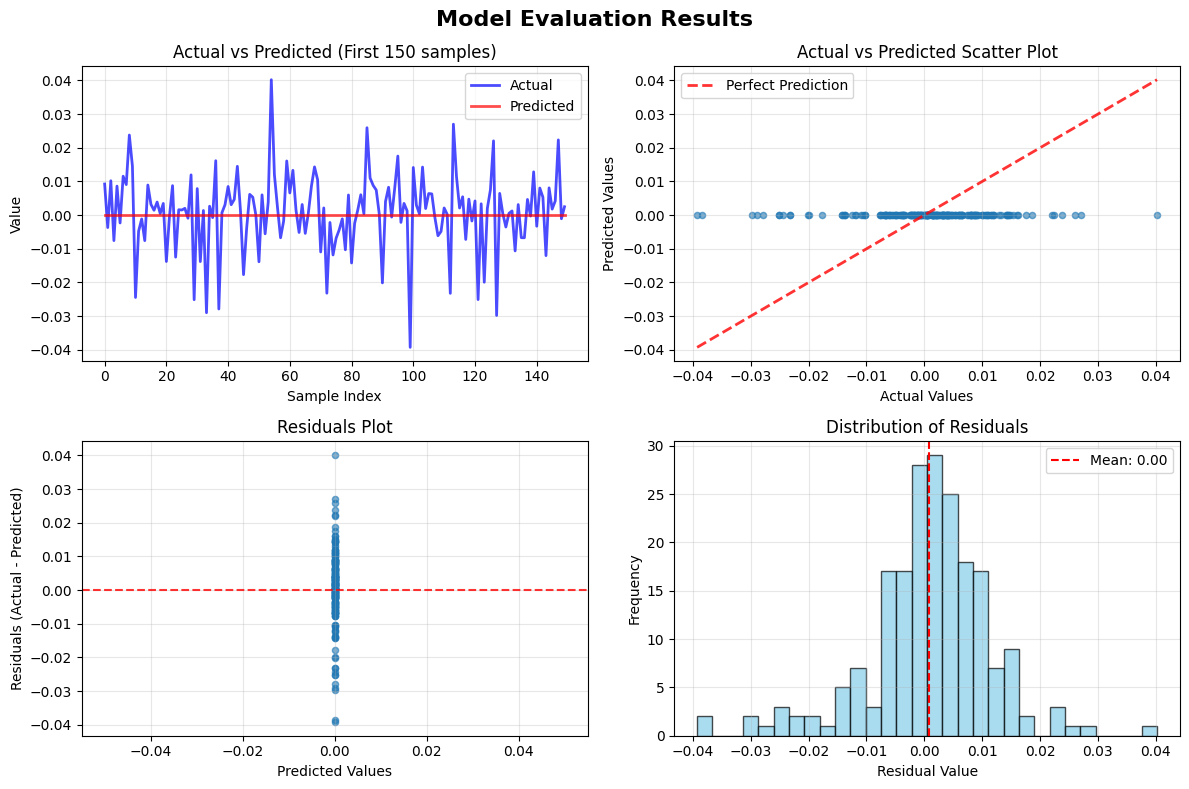

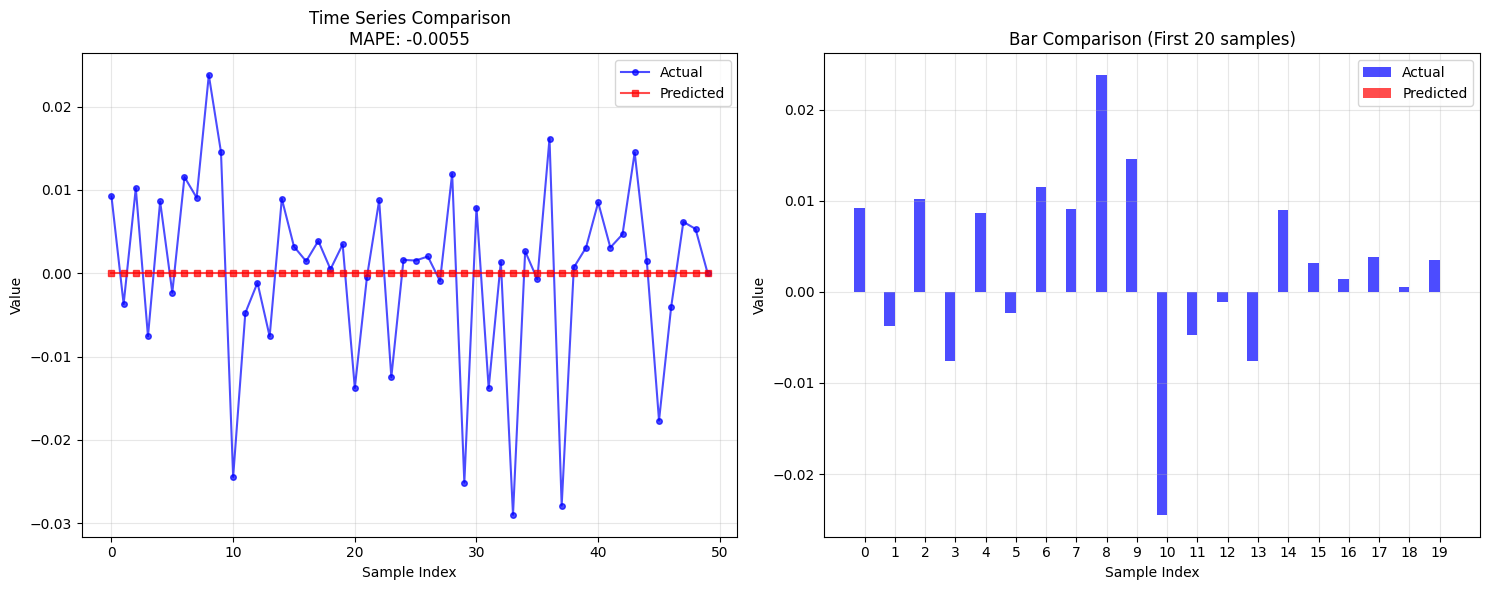

MODEL EVALUATION SUMMARY
Total samples: 203
Overall R2: -0.0055
Mean Absolute Error: 0.0077
Root Mean Square Error: 0.0108
Mean Residual: 0.0008
Std Residual: 0.0108
Min Residual: -0.0393
Max Residual: 0.0402
Predictions set to 0 (< 50): 203/203 (100.0%)
CatBoostRegressor R2 loss : -0.546364150074008


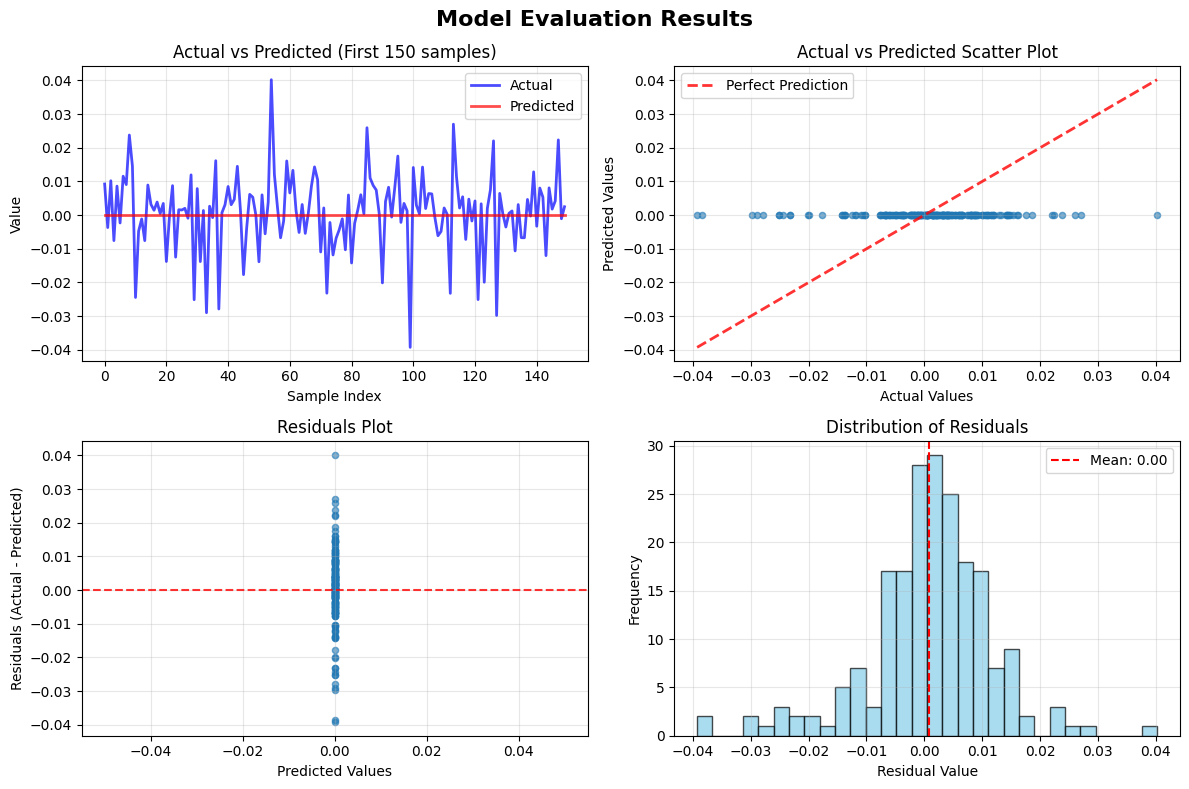

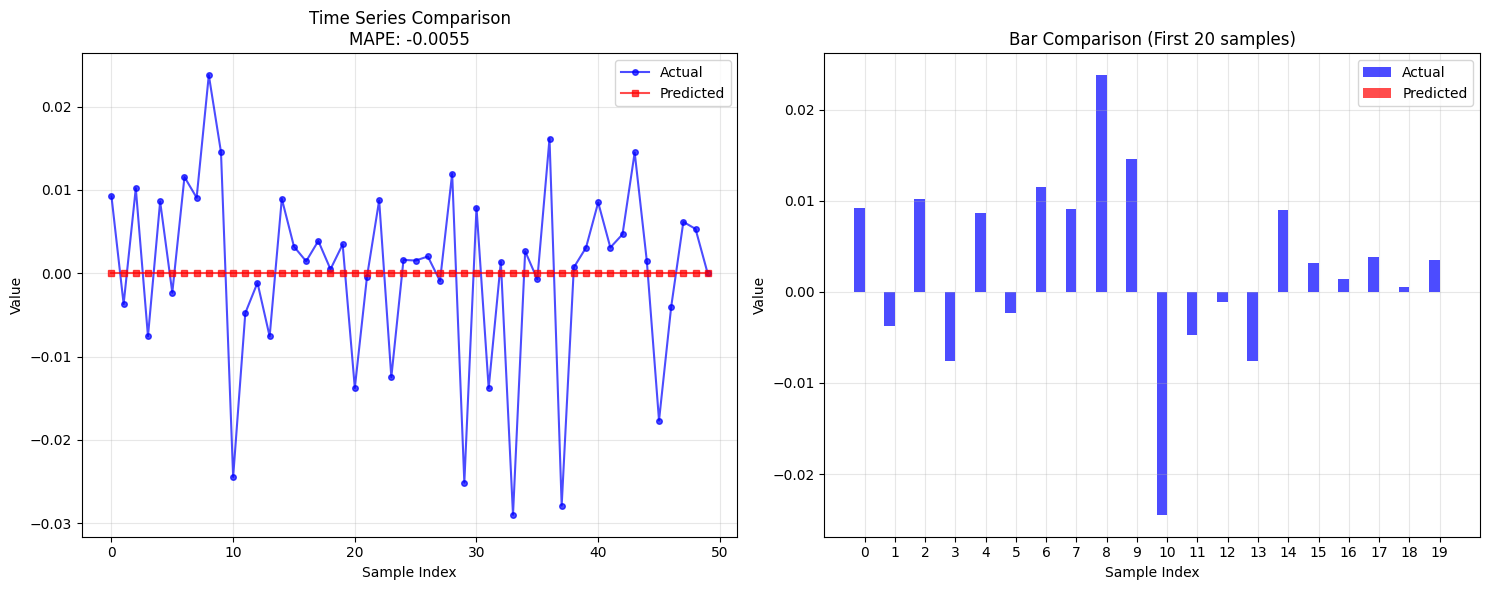

MODEL EVALUATION SUMMARY
Total samples: 203
Overall R2: -0.0055
Mean Absolute Error: 0.0077
Root Mean Square Error: 0.0108
Mean Residual: 0.0008
Std Residual: 0.0108
Min Residual: -0.0393
Max Residual: 0.0402
Predictions set to 0 (< 50): 203/203 (100.0%)
LGBMRegressor R2 loss : -0.546364150074008%


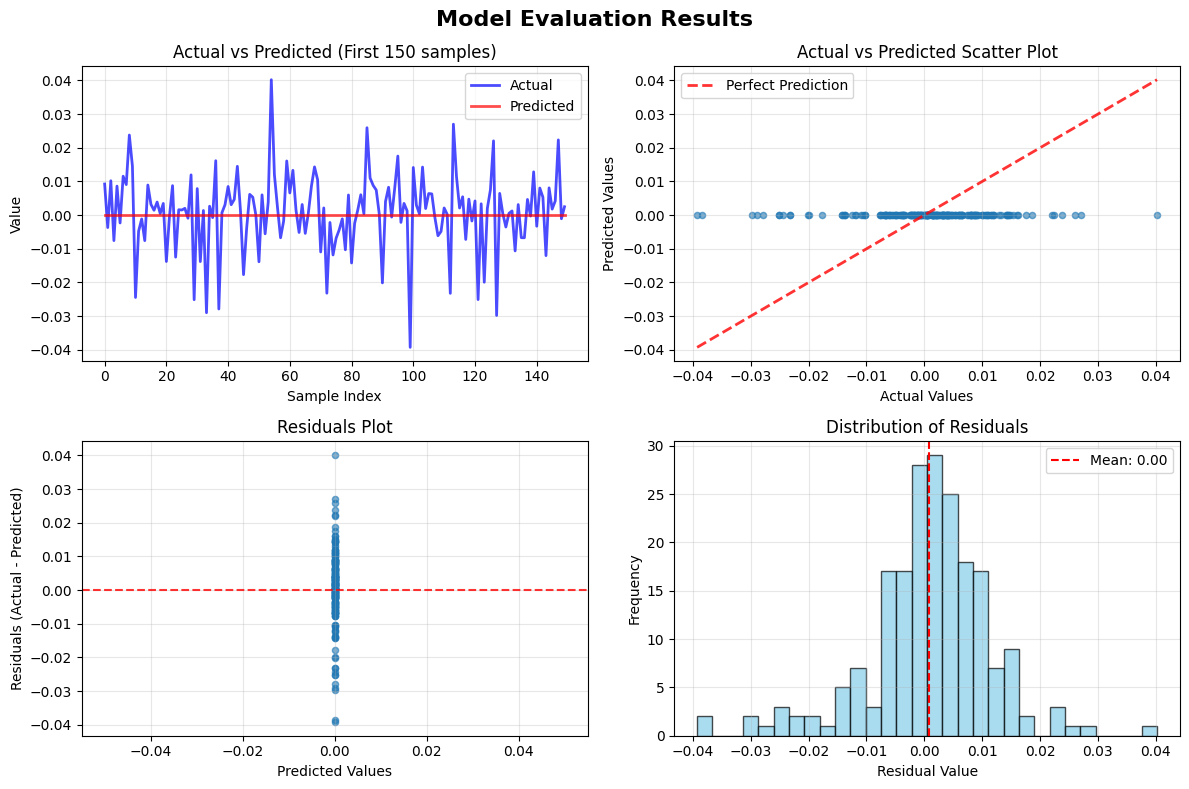

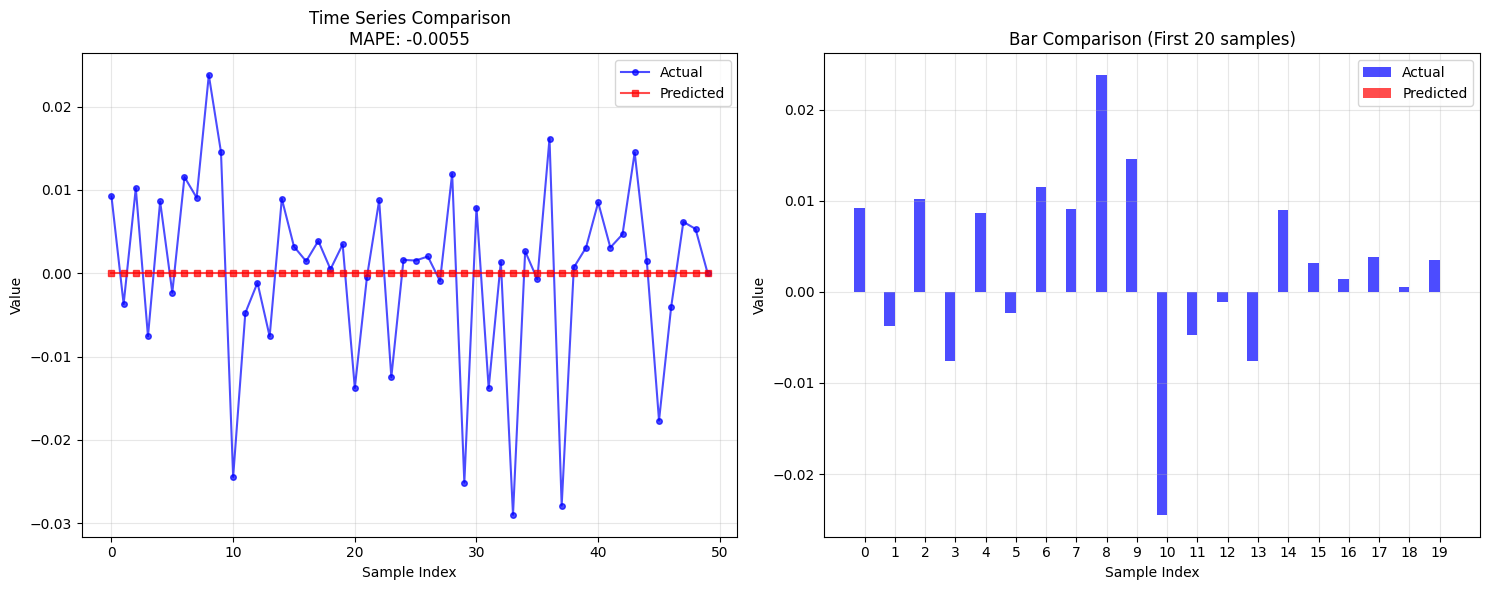

MODEL EVALUATION SUMMARY
Total samples: 203
Overall R2: -0.0055
Mean Absolute Error: 0.0077
Root Mean Square Error: 0.0108
Mean Residual: 0.0008
Std Residual: 0.0108
Min Residual: -0.0393
Max Residual: 0.0402
Predictions set to 0 (< 50): 203/203 (100.0%)
RandomForestRegressor R2 loss : -0.546364150074008%


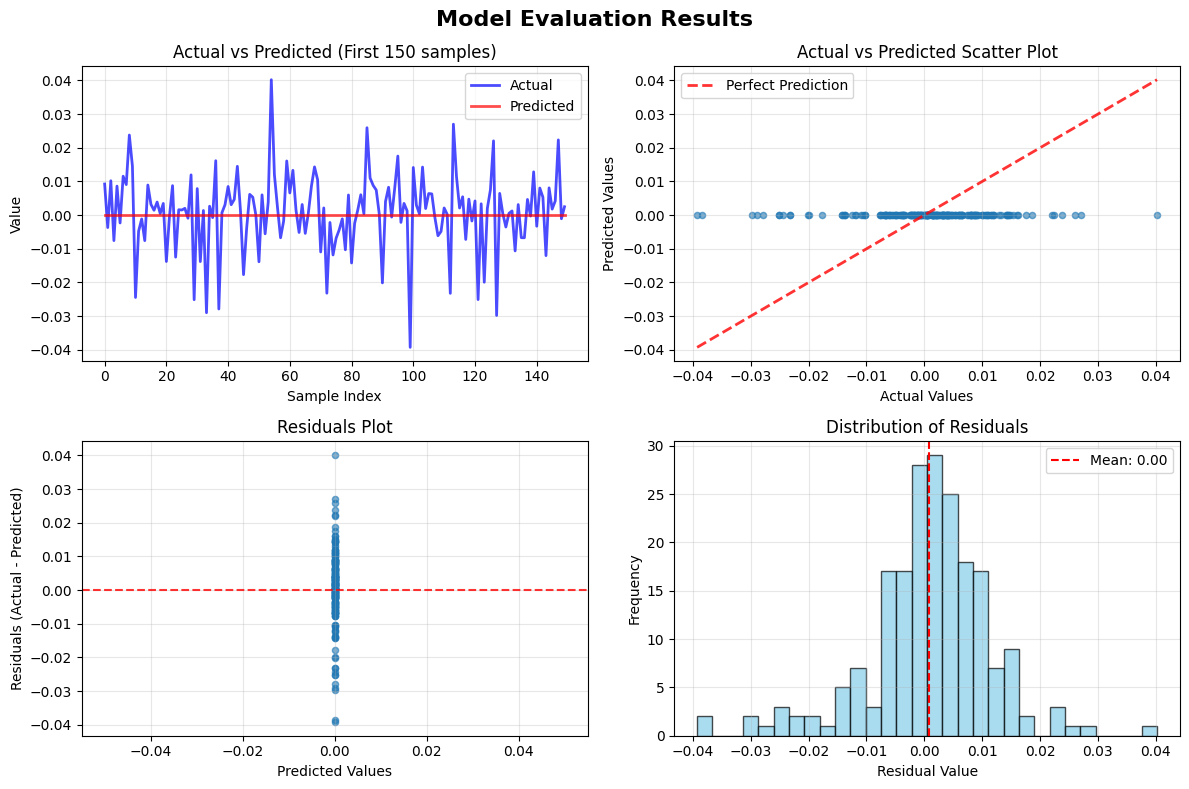

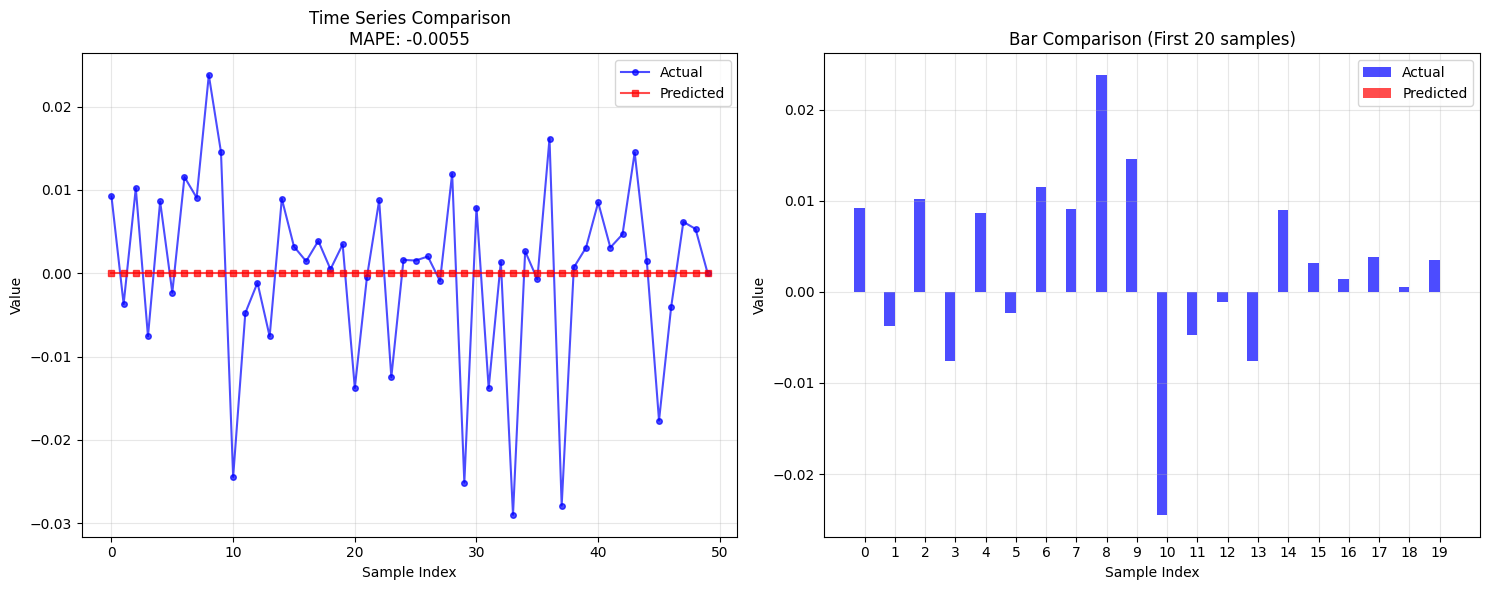

MODEL EVALUATION SUMMARY
Total samples: 203
Overall R2: -0.0055
Mean Absolute Error: 0.0077
Root Mean Square Error: 0.0108
Mean Residual: 0.0008
Std Residual: 0.0108
Min Residual: -0.0393
Max Residual: 0.0402
Predictions set to 0 (< 50): 203/203 (100.0%)
ExtraTreesRegressor R2 loss : -0.546364150074008%


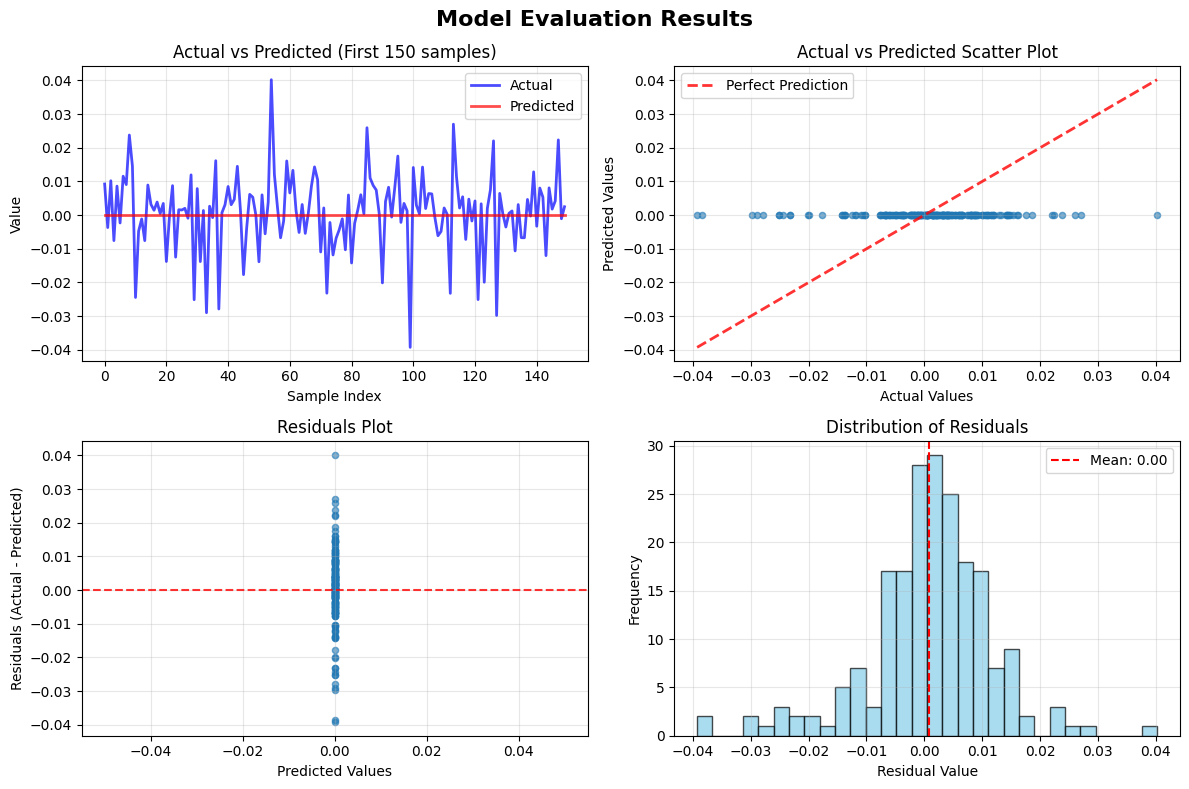

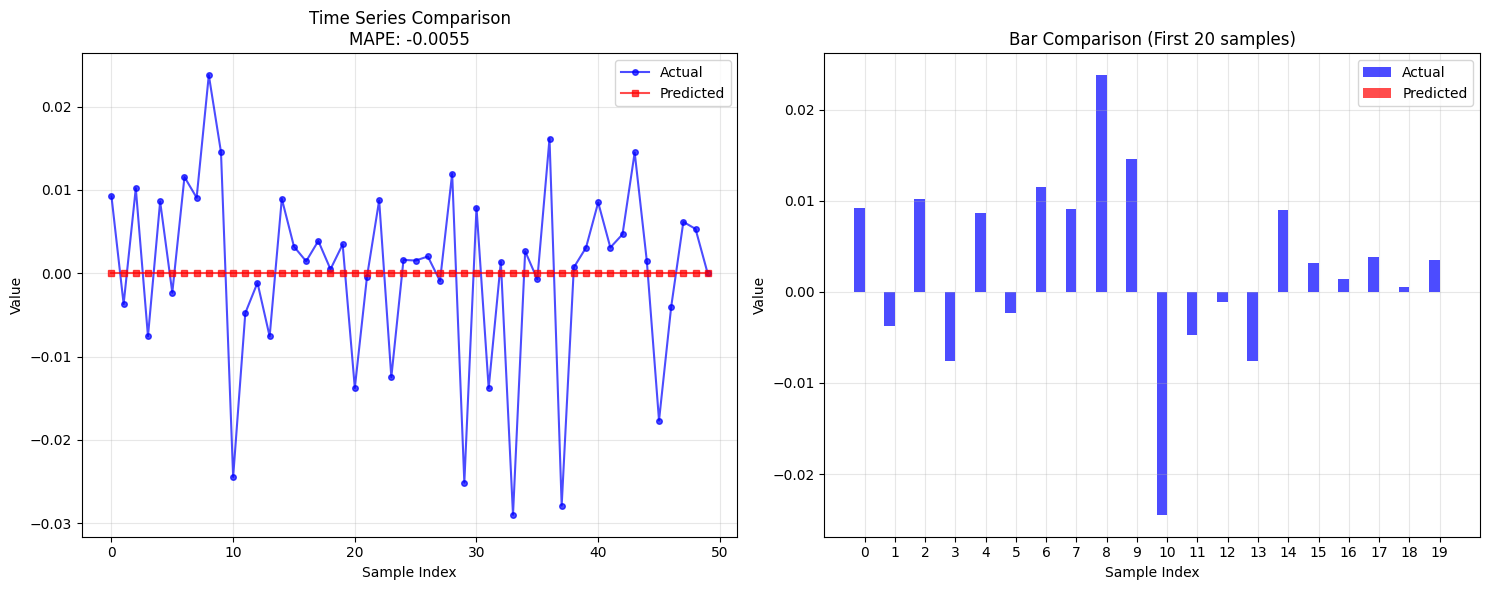

MODEL EVALUATION SUMMARY
Total samples: 203
Overall R2: -0.0055
Mean Absolute Error: 0.0077
Root Mean Square Error: 0.0108
Mean Residual: 0.0008
Std Residual: 0.0108
Min Residual: -0.0393
Max Residual: 0.0402
Predictions set to 0 (< 50): 203/203 (100.0%)
GradientBoostingRegressor R2 loss : -0.546364150074008%


In [7]:
catboost_compiler = score_compiler(catboost, test_x, test_y)
catboost_y_pred, catboost_mape_loss, catboost_total_loss = catboost_compiler.evaluate(plot=True, n_samples=150)
catboost_compiler.create_detailed_comparison_plot(n_samples=50)
catboost_compiler.print_evaluation_summary()
print(f'CatBoostRegressor R2 loss : {catboost_total_loss*100}')

LGBM_R_compiler = score_compiler(LGBM_R, test_x, test_y)
LGBM_R_y_pred, LGBM_R_mape_loss, LGBM_R_total_loss = LGBM_R_compiler.evaluate(plot=True, n_samples=150)
LGBM_R_compiler.create_detailed_comparison_plot(n_samples=50)
LGBM_R_compiler.print_evaluation_summary()
print(f'LGBMRegressor R2 loss : {LGBM_R_total_loss*100}%')

random_compiler = score_compiler(random_forest, test_x, test_y)
random_y_pred, random_mape_loss, random_total_loss = random_compiler.evaluate(plot=True, n_samples=150)
random_compiler.create_detailed_comparison_plot(n_samples=50)
random_compiler.print_evaluation_summary()
print(f'RandomForestRegressor R2 loss : {random_total_loss*100}%')

extra_compiler = score_compiler(extra_trees, test_x, test_y)
extra_y_pred, extra_mape_loss, extra_total_loss = extra_compiler.evaluate(plot=True, n_samples=150)
extra_compiler.create_detailed_comparison_plot(n_samples=50)
extra_compiler.print_evaluation_summary()
print(f'ExtraTreesRegressor R2 loss : {extra_total_loss*100}%')

Gradient_compiler = score_compiler(GradientBoosting, test_x, test_y)
Gradient_y_pred, Gradient_mape_loss, Gradient_total_loss = Gradient_compiler.evaluate(plot=True, n_samples=150)
Gradient_compiler.create_detailed_comparison_plot(n_samples=50)
Gradient_compiler.print_evaluation_summary()
print(f'GradientBoostingRegressor R2 loss : {Gradient_total_loss*100}%')

In [8]:
import numpy

def predict_full(catboost_y_pred, LGBM_R_y_pred, random_y_pred, extra_y_pred, Gradient_y_pred):
    config={
            "catboost" : 0.4,
            "LGBM_R"   : 0.3,
            "random"   : 0.5,
            "extra"    : 0.4,
            "Gradient" : 0.3
           }
    final=(numpy.array(catboost_y_pred)*config['catboost']+
           numpy.array(LGBM_R_y_pred)*config['LGBM_R']+
           numpy.array(random_y_pred)*config['random']+
           numpy.array(extra_y_pred)*config['extra']+
           numpy.array(Gradient_y_pred)*config['Gradient'])[0]
    final/=sum(config.values())

    return final

def submission_compiler(y_pred, test_y):
    mape_loss = []
    total_loss = mean_absolute_percentage_error(test_y, y_pred)
    for actual, predected in zip(y_pred, test_y):
        mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
    return y_pred, numpy.array(mape_loss), total_loss

def predict(test: pl.DataFrame) -> float:
    test = test.to_pandas()
    test = preprocessing(test, "test")
    
    catboost_y_pred = catboost.predict(test)
    LGBM_R_y_pred = LGBM_R.predict(test)
    random_y_pred = random_forest.predict(test)
    extra_y_pred = extra_trees.predict(test)
    Gradient_y_pred = GradientBoosting.predict(test)
    
    final_y_pre = predict_full(catboost_y_pred, LGBM_R_y_pred, random_y_pred, extra_y_pred, Gradient_y_pred)
    return final_y_pre
    
inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    inference_server.serve()
else:
    inference_server.run_local_gateway(('/kaggle/input/hull-tactical-market-prediction/',))